# TED 02 - Limpeza, Saneamento e Análise Exploratória
Projeto: Da Roça Inteligente

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../../data/raw/retail_store_inventory.csv')
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


## 1. Inspeção inicial

In [2]:
print('Dimensões:', df.shape)
print(df.info())
print('\nAusentes por coluna:')
print(df.isna().sum())
print('Duplicados:', df.duplicated().sum())

Dimensões: (73100, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), objec

## 2. Ajuste de tipos e validações

In [3]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
num_cols=['Inventory Level','Units Sold','Units Ordered','Demand Forecast','Price','Discount','Competitor Pricing']
for c in num_cols:
    print(c, 'negativos:', (df[c] < 0).sum())

Inventory Level negativos: 0
Units Sold negativos: 0
Units Ordered negativos: 0
Demand Forecast negativos: 673
Price negativos: 0
Discount negativos: 0
Competitor Pricing negativos: 0


Foram encontrados 673 valores negativos em `Demand Forecast`. Como demanda representa quantidade esperada e não possui interpretação operacional negativa neste projeto, esses valores são ajustados para zero. Os demais valores extremos são mantidos e analisados, pois podem representar dias de alta demanda.

In [4]:
negative_forecast = (df['Demand Forecast'] < 0).sum()
df.loc[df['Demand Forecast'] < 0, 'Demand Forecast'] = 0
print('Previsões negativas tratadas:', negative_forecast)

Previsões negativas tratadas: 673


## 3. Estatísticas descritivas

In [5]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Inventory Level,73100.0,274.469877,129.949514,50.00,162.00,273.000,387.0000,500.00
Units Sold,73100.0,136.464870,108.919406,0.00,49.00,107.000,203.0000,499.00
Units Ordered,73100.0,110.004473,52.277448,20.00,65.00,110.000,155.0000,200.00
Demand Forecast,73100.0,141.528727,109.209174,0.00,53.67,113.015,208.0525,518.55
Price,73100.0,55.135108,26.021945,10.00,32.65,55.050,77.8600,100.00
Discount,73100.0,10.009508,7.083746,0.00,5.00,10.000,15.0000,20.00
Competitor Pricing,73100.0,55.146077,26.191408,5.03,32.68,55.010,77.8200,104.94


## 4. Outliers pelo critério IQR

In [6]:
for c in num_cols:
    q1,q3=df[c].quantile([.25,.75]); iqr=q3-q1
    lo=q1-1.5*iqr; hi=q3+1.5*iqr
    n=((df[c]<lo)|(df[c]>hi)).sum()
    print(c, 'limites:', round(lo,2), round(hi,2), 'possíveis outliers:', n)

Inventory Level limites: -175.5 724.5 possíveis outliers: 0
Units Sold limites: -182.0 434.0 possíveis outliers: 715
Units Ordered limites: -70.0 290.0 possíveis outliers: 0
Demand Forecast limites: -177.9 439.63 possíveis outliers: 732
Price limites: -35.16 145.68 possíveis outliers: 0
Discount limites: -10.0 30.0 possíveis outliers: 0
Competitor Pricing limites: -35.03 145.53 possíveis outliers: 0


## 5. Análise exploratória

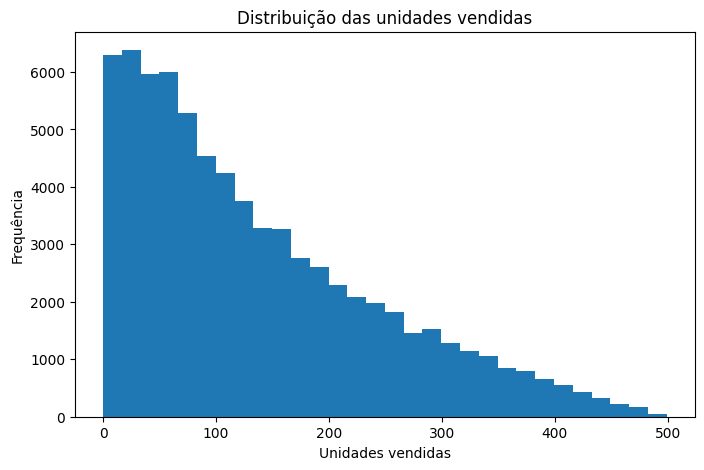

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df['Units Sold'], bins=30)
plt.title('Distribuição das unidades vendidas')
plt.xlabel('Unidades vendidas'); plt.ylabel('Frequência'); plt.show()

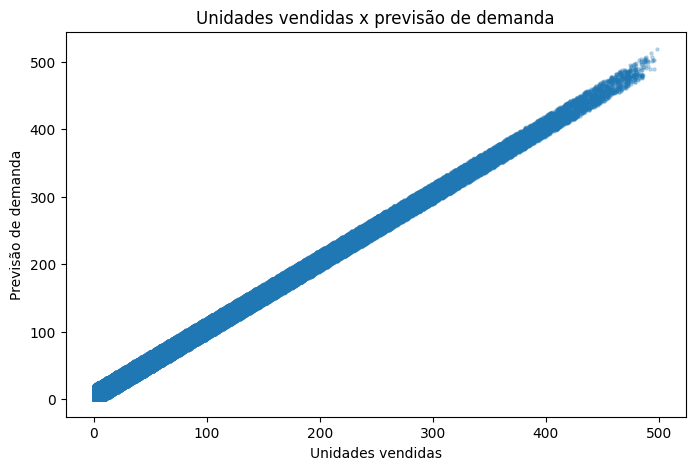

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(df['Units Sold'], df['Demand Forecast'], s=5, alpha=.25)
plt.title('Unidades vendidas x previsão de demanda')
plt.xlabel('Unidades vendidas'); plt.ylabel('Previsão de demanda'); plt.show()

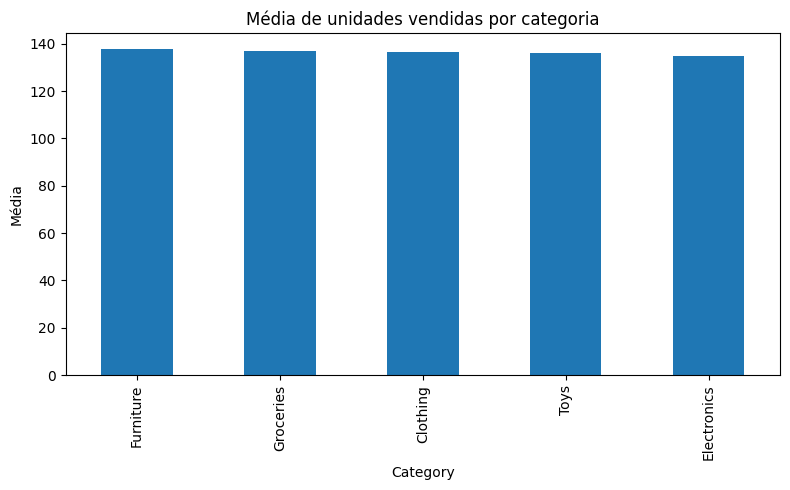

In [9]:
df.groupby('Category')['Units Sold'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(8,5))
plt.title('Média de unidades vendidas por categoria'); plt.ylabel('Média'); plt.tight_layout(); plt.show()

In [10]:
cols=['Inventory Level','Units Sold','Units Ordered','Demand Forecast','Price','Discount','Holiday/Promotion','Competitor Pricing']
print(df[cols].corr().round(3))

                    Inventory Level  ...  Competitor Pricing
Inventory Level               1.000  ...               0.009
Units Sold                    0.590  ...               0.001
Units Ordered                 0.001  ...               0.005
Demand Forecast               0.589  ...               0.001
Price                         0.009  ...               0.994
Discount                      0.005  ...               0.002
Holiday/Promotion             0.003  ...               0.002
Competitor Pricing            0.009  ...               1.000

[8 rows x 8 columns]


## 6. Exportação da base tratada

In [11]:
df.to_csv('../../data/processed/retail_store_inventory_processed.csv', index=False)